# DSB Forecasting Pipeline — Tier 1
## Econometric Forecasting: Stationarity → Structural Breaks → ARIMA/ARIMAX → GARCH/EGARCH

**Datasets:** Gold (1915–2026), Silver (1915–2026), Brent Oil (1946–2026), USDG stablecoin (2025–2026)  
**Literature:**
- Gupta, Karmakar & Pierdzioch (2024) — RF + GPR for gold volatility (*Computational Economics*)
- Foroutan & Lahmiri (2024) — TCN/BiGRU commodity forecasting (*Financial Innovation*)
- Ahmed & Aldasoro (2026) — Stablecoin–Treasury nexus (BIS WP 1270)

> ⚠️ All forecasts are model estimates, not guarantees. See the disclaimer in the "Summary — Tier 1 Complete" section at the end of this notebook.

In [1]:
%pip install -q statsmodels arch ruptures pandas-datareader scipy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from arch import arch_model
from scipy import stats

try:
    import ruptures as rpt
    HAS_RUPTURES = True
except ImportError:
    HAS_RUPTURES = False

try:
    import pandas_datareader.data as web
    HAS_PDR = True
except ImportError:
    HAS_PDR = False

plt.rcParams.update({'figure.figsize': (14, 5), 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_style('whitegrid')
np.random.seed(42)

DATA_DIR     = Path('../../01_Raw_Data')
OUTPUT_DIR   = Path('../../04_Outputs')
EXTERNAL_DIR = Path('../../data/external')
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

# Known global events for chart annotations
EVENTS = {
    '1971-08': 'Nixon Shock',
    '1980-01': 'Hunt Silver Corner',
    '2008-09': 'GFC 2008',
    '2011-09': 'Gold ATH $1,900',
    '2020-03': 'COVID-19',
    '2022-02': 'Russia-Ukraine',
    '2026-01': 'Iran-Hormuz',
}

print('Libraries loaded OK')
print(f'ruptures available: {HAS_RUPTURES} | pandas_datareader: {HAS_PDR}')

Libraries loaded OK
ruptures available: True | pandas_datareader: True


---
## Section 1 — Data Loading & Feature Engineering (T1.1)

In [3]:
def load_monthly(filename, col):
    df = pd.read_csv(DATA_DIR / filename)
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df = df.rename(columns={'Value': col}).set_index('Date').sort_index()
    # to_timestamp() without args defaults to period start (= month start for 'M')
    df.index = df.index.to_period('M').to_timestamp()
    return df

gold   = load_monthly('gold100years.csv',  'gold')
silver = load_monthly('silver100years.csv','silver')
brent  = load_monthly('brentOil.csv',      'brent')

usdg = pd.read_csv(DATA_DIR / 'USDG.csv', parse_dates=['Date'], index_col='Date').sort_index()
usdg = usdg[~usdg.index.duplicated(keep='first')]  # remove 1 known duplicate

for name, df, col in [('Gold', gold, 'gold'), ('Silver', silver, 'silver'), ('Brent', brent, 'brent')]:
    print(f'{name:8s}: {df.index[0].date()} – {df.index[-1].date()}, {len(df):>5} obs,'
          f'  latest={df[col].iloc[-1]:,.2f}')
print(f'USDG    : {usdg.index[0].date()} – {usdg.index[-1].date()}, {len(usdg):>5} obs (daily)')

Gold    : 1915-01-01 – 2026-04-01,  1336 obs,  latest=4,712.89
Silver  : 1915-01-01 – 2026-04-01,  1336 obs,  latest=88.36
Brent   : 1946-01-01 – 2026-03-01,   963 obs,  latest=102.86
USDG    : 2025-04-29 – 2026-04-28,   365 obs (daily)


In [4]:
# Log prices (level) and log returns (first difference) — standard for commodity series
for df, col in [(gold, 'gold'), (silver, 'silver'), (brent, 'brent')]:
    df['log_p'] = np.log(df[col])
    df['ret']   = df['log_p'].diff()   # log return = d(log_p)

# USDG: price is pegged near $1, so model deviation and market cap separately
usdg['peg_dev']    = usdg['Price_USD'] - 1.0
usdg['log_mktcap'] = np.log(usdg['MarketCap_USD'])
usdg['mktcap_ret'] = usdg['log_mktcap'].diff()

assets = {'Gold': (gold, 'gold'), 'Silver': (silver, 'silver'), 'Brent': (brent, 'brent')}

# Summary stats on log returns
summary = pd.DataFrame({
    name: df['ret'].describe().rename({'mean':'mean','std':'std','min':'min','max':'max'})
    for name, (df, _) in assets.items()
}).round(4)
print('Log return summary (monthly):')
summary

Log return summary (monthly):


,Gold,Silver,Brent
count,1335.0000,1335.0000,962.0000
mean,0.0041,0.0039,0.0016
std,0.0416,0.0763,0.0832
min,-0.2404,-0.9681,-0.7798
25%,-0.0014,-0.0090,-0.0136
50%,0.0000,0.0000,-0.0026
75%,0.0069,0.0108,0.0266
max,0.2793,0.5275,0.8438


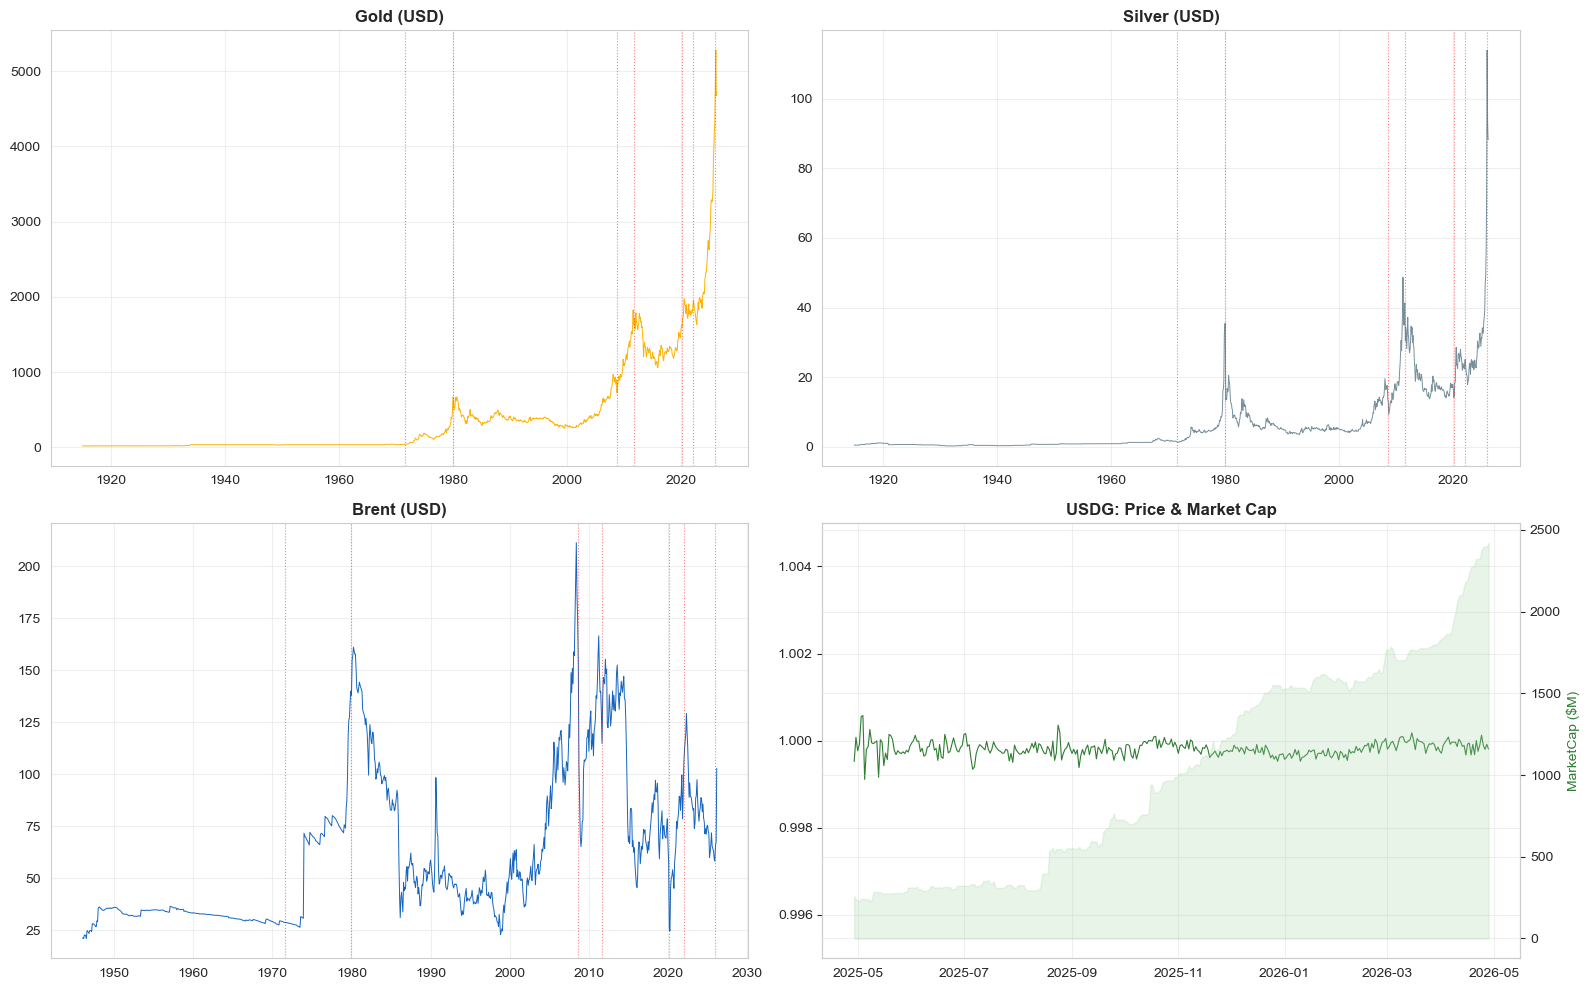

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = {'Gold': '#FFB300', 'Silver': '#78909C', 'Brent': '#1565C0'}

for ax, (name, (df, col)), c in zip(axes.flat[:3], assets.items(), colors.values()):
    ax.plot(df.index, df[col], color=c, linewidth=0.7)
    for ev_date, ev_label in EVENTS.items():
        ed = pd.Timestamp(ev_date)
        if df.index[0] <= ed <= df.index[-1]:
            ax.axvline(ed, color='red', linestyle=':', alpha=0.5, linewidth=0.8)
    ax.set_title(f'{name} (USD)', fontweight='bold')

ax4 = axes[1, 1]
ax4.plot(usdg.index, usdg['Price_USD'], color='#2E7D32', linewidth=0.8, label='Price')
ax4b = ax4.twinx()
ax4b.fill_between(usdg.index, usdg['MarketCap_USD']/1e6, alpha=0.25, color='#A5D6A7')
ax4b.set_ylabel('MarketCap ($M)', color='#2E7D32')
ax4.set_title('USDG: Price & Market Cap', fontweight='bold')
ax4.set_ylim(0.995, 1.005)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'price_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — Stationarity Tests: ADF + KPSS (T1.1)

- **ADF** H₀: unit root (non-stationary). p < 0.05 → reject H₀ → stationary.
- **KPSS** H₀: stationary. p < 0.05 → reject H₀ → non-stationary.
- Both agree → definitive verdict; conflict → inconclusive (common at borderline cases).

In [6]:
def stationarity_row(series, label, alpha=0.05):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    try:
        kpss_stat, kpss_p, _, _ = kpss(s, regression='ct', nlags='auto')
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan

    adf_ok  = adf_p  < alpha          # True → stationary
    kpss_ok = kpss_p >= alpha          # True → stationary (fail to reject H0)

    if adf_ok and kpss_ok:
        verdict = 'STATIONARY'
    elif not adf_ok and not kpss_ok:
        verdict = 'NON-STATIONARY'
    else:
        verdict = 'INCONCLUSIVE'

    return {
        'Series': label,
        'ADF stat': round(adf_stat, 3),
        'ADF p': round(adf_p, 4),
        'KPSS stat': round(kpss_stat, 3),
        'KPSS p': round(kpss_p, 4),
        'Verdict': verdict,
    }

rows = []
for name, (df, col) in assets.items():
    rows.append(stationarity_row(df['log_p'], f'{name} — log price'))
    rows.append(stationarity_row(df['ret'],   f'{name} — log return'))

rows.append(stationarity_row(usdg['log_mktcap'], 'USDG — log MarketCap'))
rows.append(stationarity_row(usdg['mktcap_ret'], 'USDG — MarketCap return'))
rows.append(stationarity_row(usdg['peg_dev'],    'USDG — peg deviation'))

stat_df = pd.DataFrame(rows)

# Colour verdict column
def colour_verdict(val):
    if val == 'STATIONARY':     return 'background-color: #C8E6C9'
    if val == 'NON-STATIONARY': return 'background-color: #FFCDD2'
    return 'background-color: #FFF9C4'

stat_df.style.applymap(colour_verdict, subset=['Verdict'])

C:\Users\hadi\AppData\Local\Temp\ipykernel_37356\3642166241.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression='ct', nlags='auto')
C:\Users\hadi\AppData\Local\Temp\ipykernel_37356\3642166241.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression='ct', nlags='auto')
C:\Users\hadi\AppData\Local\Temp\ipykernel_37356\3642166241.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression='ct', nlags='auto')
C:\Users\hadi\AppData\Local\Temp\ipykernel_37356\3642166241.py:5: InterpolationWarning: The test sta

,Series,ADF stat,ADF p,KPSS stat,KPSS p,Verdict
0,Gold — log price,0.690000,0.989600,0.723000,0.010000,NON-STATIONARY
1,Gold — log return,-7.080000,0.000000,0.077000,0.100000,STATIONARY
2,Silver — log price,0.321000,0.978300,0.444000,0.010000,NON-STATIONARY
3,Silver — log return,-36.205000,0.000000,0.042000,0.100000,STATIONARY
4,Brent — log price,-2.507000,0.113800,0.179000,0.024100,NON-STATIONARY
5,Brent — log return,-16.697000,0.000000,0.028000,0.100000,STATIONARY
6,USDG — log MarketCap,-0.729000,0.839000,0.444000,0.010000,NON-STATIONARY
7,USDG — MarketCap return,-8.813000,0.000000,0.084000,0.100000,STATIONARY
8,USDG — peg deviation,-3.634000,0.005100,0.247000,0.010000,INCONCLUSIVE


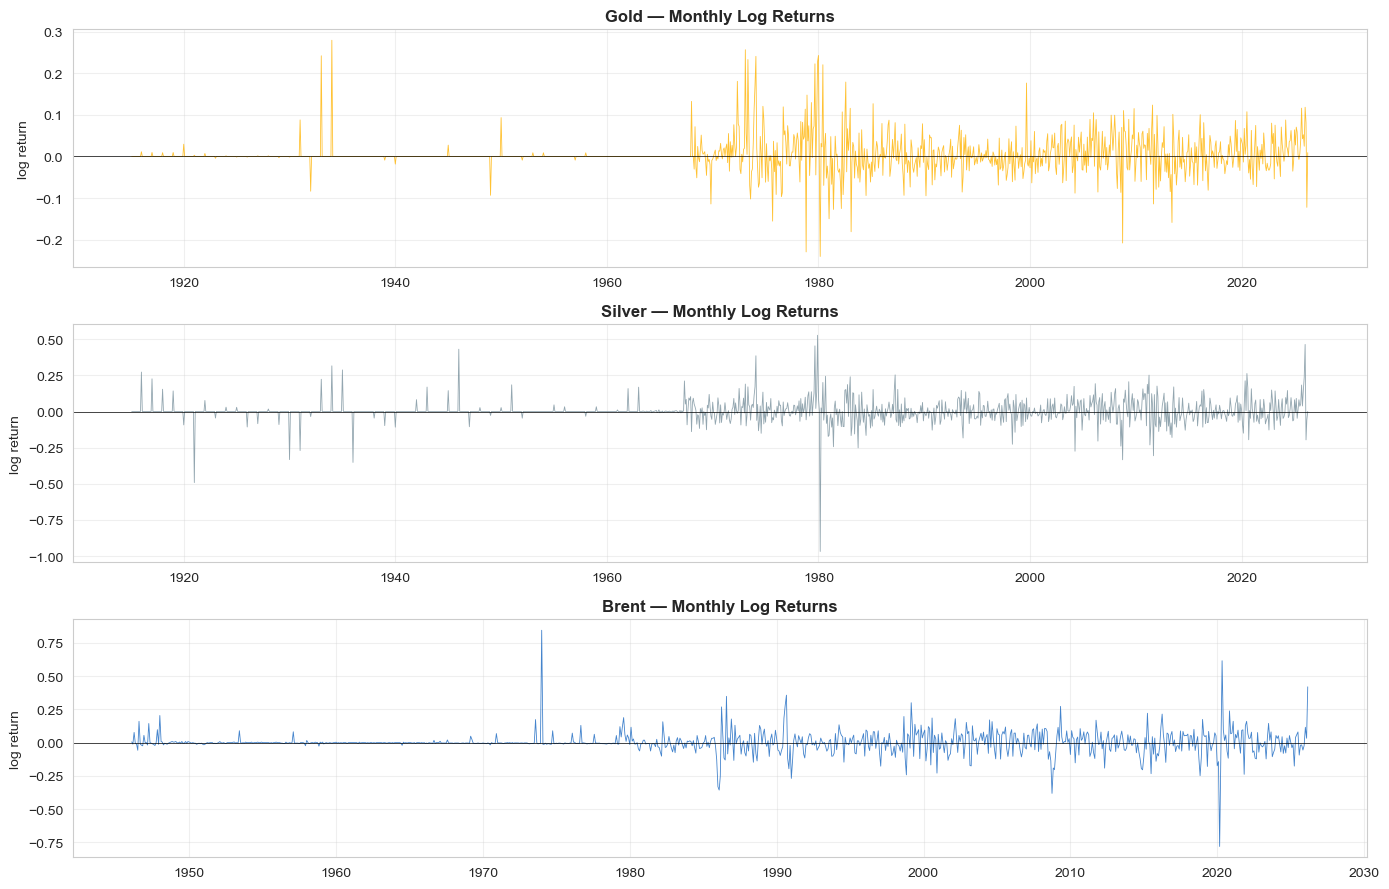

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
for ax, (name, (df, col)), c in zip(axes, assets.items(), colors.values()):
    ax.plot(df.index[1:], df['ret'].dropna(), color=c, linewidth=0.6, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{name} — Monthly Log Returns', fontweight='bold')
    ax.set_ylabel('log return')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'log_returns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Structural Break Detection (T1.2)

CUSUM of OLS residuals (linear trend model) detects sustained departures from trend.  
ruptures PELT algorithm detects sharp change-points in variance/level.

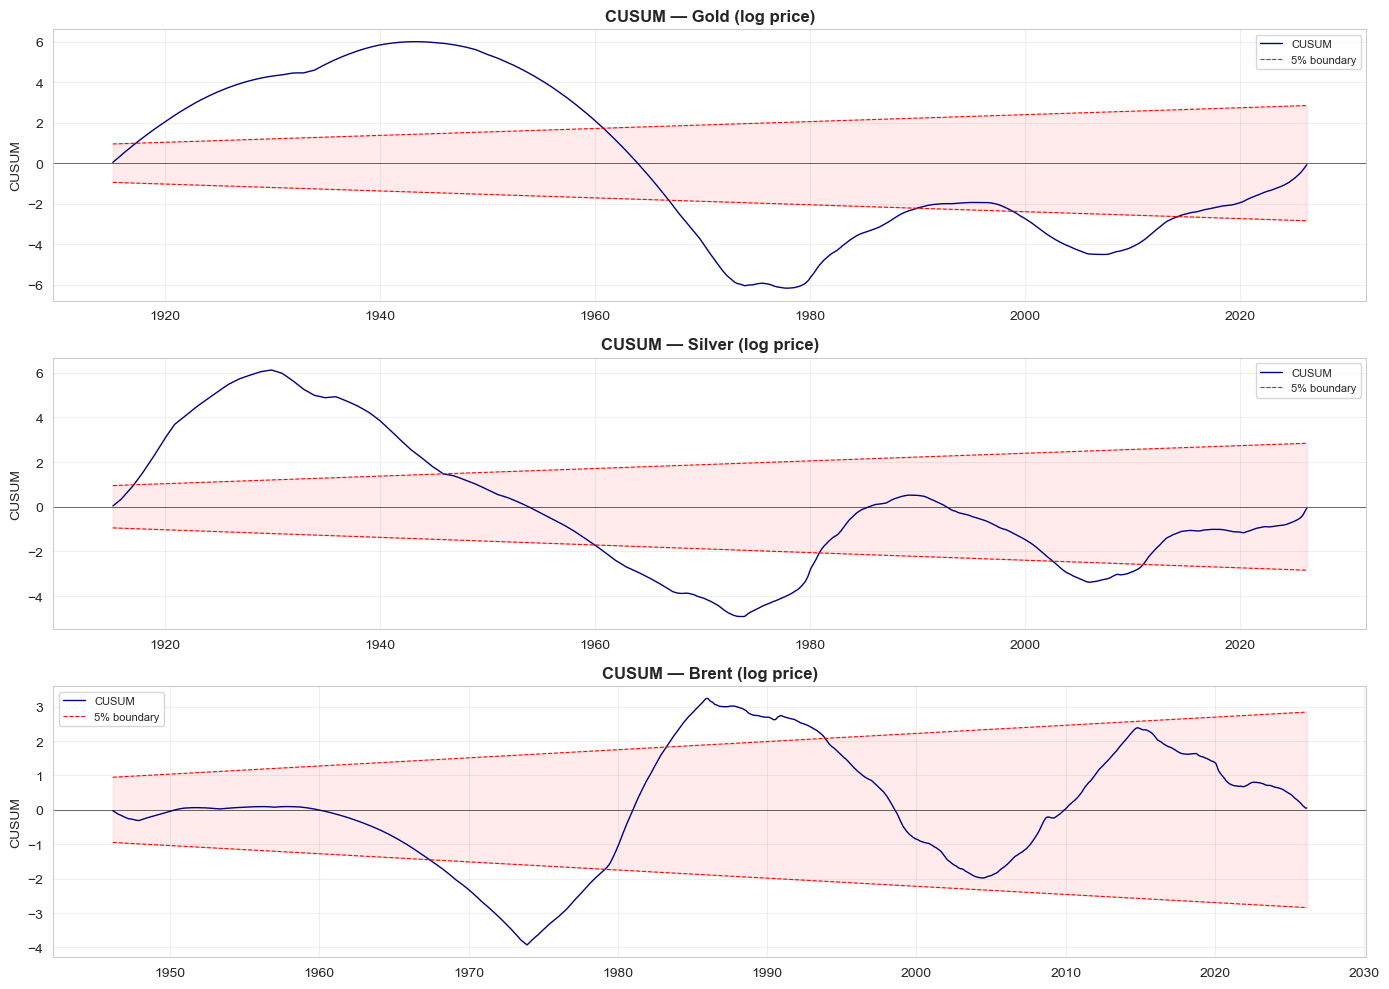

In [8]:
def cusum_stats(series):
    """Recursive CUSUM of OLS residuals (Brown, Durbin & Evans 1975)."""
    s = series.dropna().values
    n = len(s)
    t = np.arange(n)
    X = sm.add_constant(t)
    res = sm.OLS(s, X).fit()
    e   = res.resid
    sigma = np.std(e, ddof=2)
    cusum = np.cumsum(e[2:]) / (sigma * np.sqrt(n))
    # 5% critical boundary: a + 2a*(t-k)/(n-k), a=0.948 (Brown et al.)
    a = 0.948
    k = 2
    time_frac = np.arange(k, n)
    bound = a + 2 * a * (time_frac - k) / (n - k)
    return cusum, bound

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, (name, (df, col)), c in zip(axes, assets.items(), colors.values()):
    cusum, bound = cusum_stats(df['log_p'])
    idx = df.index[2:]
    ax.plot(idx, cusum,  color='navy',  linewidth=1.0, label='CUSUM')
    ax.plot(idx,  bound, color='red',   linewidth=0.8, linestyle='--', label='5% boundary')
    ax.plot(idx, -bound, color='red',   linewidth=0.8, linestyle='--')
    ax.fill_between(idx, -bound, bound, alpha=0.08, color='red')
    ax.axhline(0, color='black', linewidth=0.4)
    ax.set_title(f'CUSUM — {name} (log price)', fontweight='bold')
    ax.set_ylabel('CUSUM')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cusum_tests.png', dpi=150, bbox_inches='tight')
plt.show()

Gold: 4 break(s) at ['1933-09-01', '1972-11-01', '1979-02-01', '2007-11-01']
Silver: 5 break(s) at ['1929-02-01', '1945-10-01', '1962-11-01', '1973-09-01', '2006-03-01']
Brent: 5 break(s) at ['1973-11-01', '1979-04-01', '1985-12-01', '2004-09-01', '2014-09-01']


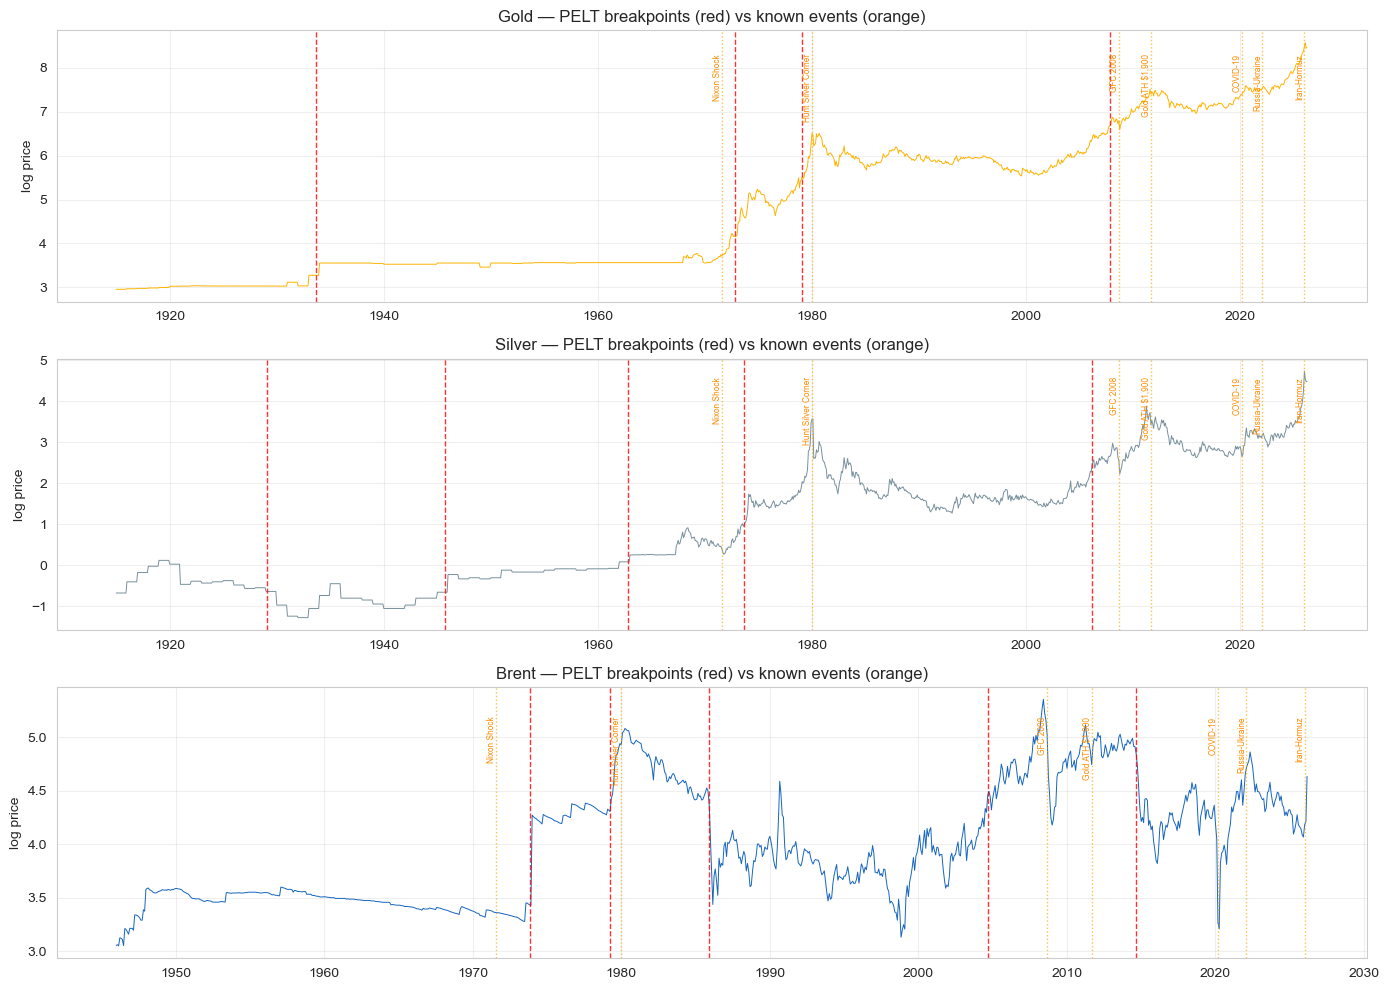

In [9]:
if HAS_RUPTURES:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    for ax, (name, (df, col)), c in zip(axes, assets.items(), colors.values()):
        s = df['log_p'].dropna()
        algo = rpt.Pelt(model='rbf').fit(s.values)
        # pen=15 trades off # of breaks vs fit; increase to get fewer breaks
        breaks = algo.predict(pen=15)[:-1]
        break_dates = s.index[np.array(breaks) - 1]

        ax.plot(s.index, s.values, color=c, linewidth=0.7)
        for bd in break_dates:
            ax.axvline(bd, color='red', linestyle='--', linewidth=1.0, alpha=0.8)
        # known events
        for ev_date, ev_label in EVENTS.items():
            ed = pd.Timestamp(ev_date)
            if s.index[0] <= ed <= s.index[-1]:
                ax.axvline(ed, color='orange', linestyle=':', linewidth=1.0, alpha=0.7)
                ax.text(ed, s.max() * 0.97, ev_label, rotation=90,
                        fontsize=6, va='top', ha='right', color='darkorange')

        ax.set_title(f'{name} — PELT breakpoints (red) vs known events (orange)')
        ax.set_ylabel('log price')
        print(f'{name}: {len(break_dates)} break(s) at {[str(d.date()) for d in break_dates]}')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'structural_breaks.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('ruptures not installed. Run: pip install ruptures')

---
## Section 4 — Train/Test Split & Walk-Forward Validation (T1.3)

- Monthly assets: cutoff = **2024-04-01** → ~24-month test window
- USDG (daily): cutoff = last 90 days
- Walk-forward (rolling-origin): training window expands one step at a time

In [10]:
CUTOFF_M = pd.Timestamp('2024-04-01')
CUTOFF_USDG = usdg.index[-90]

def time_split(df, cutoff):
    return df[df.index < cutoff].copy(), df[df.index >= cutoff].copy()

gold_tr,   gold_te   = time_split(gold,   CUTOFF_M)
silver_tr, silver_te = time_split(silver, CUTOFF_M)
brent_tr,  brent_te  = time_split(brent,  CUTOFF_M)
usdg_tr,   usdg_te   = time_split(usdg,   CUTOFF_USDG)

print('Train/Test split summary:')
for name, tr, te in [('Gold', gold_tr, gold_te), ('Silver', silver_tr, silver_te),
                     ('Brent', brent_tr, brent_te)]:
    print(f'  {name:8s}: train={len(tr):4d} ({tr.index[0].date()}–{tr.index[-1].date()})'
          f'  test={len(te):3d} ({te.index[0].date()}–{te.index[-1].date()})')
print(f'  USDG    : train={len(usdg_tr):4d}  test={len(usdg_te):3d}')

Train/Test split summary:
  Gold    : train=1311 (1915-01-01–2024-03-01)  test= 25 (2024-04-01–2026-04-01)
  Silver  : train=1311 (1915-01-01–2024-03-01)  test= 25 (2024-04-01–2026-04-01)
  Brent   : train= 939 (1946-01-01–2024-03-01)  test= 24 (2024-04-01–2026-03-01)
  USDG    : train= 275  test= 90


In [11]:
def walk_forward_folds(n_train, n_total, step=1):
    """Yield (train_end_idx, test_end_idx) for rolling-origin CV."""
    for end in range(n_train, n_total - step + 1, step):
        yield end, end + step

# Verify fold counts
folds_gold = list(walk_forward_folds(len(gold_tr), len(gold)))
print(f'Walk-forward folds (Gold): {len(folds_gold)}')
print(f'  First fold → train up to index {folds_gold[0][0]}, test index {folds_gold[0][0]}:{folds_gold[0][1]}')
print(f'  Last  fold → train up to index {folds_gold[-1][0]}')

Walk-forward folds (Gold): 25
  First fold → train up to index 1311, test index 1311:1312
  Last  fold → train up to index 1335


---
## Section 5 — Evaluation Metrics

In [12]:
def metrics(actual, pred, in_log=False):
    """RMSE, MAE, MAPE on price level. Set in_log=True if inputs are log prices."""
    a = np.exp(np.asarray(actual)) if in_log else np.asarray(actual, dtype=float)
    p = np.exp(np.asarray(pred))   if in_log else np.asarray(pred,   dtype=float)
    rmse = np.sqrt(np.mean((a - p) ** 2))
    mae  = np.mean(np.abs(a - p))
    mape = np.mean(np.abs((a - p) / a)) * 100
    return {'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'MAPE_%': round(mape, 4)}

results    = {}   # model_key → {Model, Asset, RMSE, MAE, MAPE_%}
preds_store = {}  # model_key → np.array of log-price predictions on test set

print('Evaluation functions ready.')

Evaluation functions ready.


---
## Section 6 — Baseline Models (T1.4)

In [13]:
def naive_walk(train_logp, test_logp):
    """Random walk: predict last observed log price."""
    history = list(train_logp.dropna())
    preds = []
    for actual in test_logp:
        preds.append(history[-1])
        history.append(actual)
    return np.array(preds)

splits_monthly = [
    ('Gold',   gold_tr,   gold_te),
    ('Silver', silver_tr, silver_te),
    ('Brent',  brent_tr,  brent_te),
]

for name, tr, te in splits_monthly:
    pred_log = naive_walk(tr['log_p'], te['log_p'].values)
    key = f'Naive_{name}'
    preds_store[key] = pred_log
    results[key] = {'Model': 'Naive (RW)', 'Asset': name,
                    **metrics(te['log_p'].values, pred_log, in_log=True)}

pd.DataFrame(results).T

,Model,Asset,RMSE,MAE,MAPE_%
Naive_Gold,Naive (RW),Gold,227.497,159.5215,4.3032
Naive_Silver,Naive (RW),Silver,10.3004,5.1831,8.4503
Naive_Brent,Naive (RW),Brent,8.4314,4.9746,6.4984


---
## Section 7 — ARIMA / ARIMAX (T1.5)

- ARIMA on log prices (d=1 absorbs unit root, no pre-differencing needed)
- Order selected via AIC grid search (p=0..3, q=0..3, d=1)
- Walk-forward: refit at each step — no data leakage

In [14]:
def select_order(log_prices, p_max=3, q_max=3, d=1):
    """AIC-based grid search for ARIMA(p,d,q) order."""
    best_aic, best_order = np.inf, (1, d, 1)
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            if p == 0 and q == 0:
                continue
            try:
                res = ARIMA(log_prices, order=(p, d, q)).fit(
                    method_kwargs={'warn_convergence': False})
                if res.aic < best_aic:
                    best_aic, best_order = res.aic, (p, d, q)
            except Exception:
                pass
    return best_order

print('Selecting ARIMA orders via AIC grid search...')
ORDERS = {}
for name, tr, te in splits_monthly:
    ORDERS[name] = select_order(tr['log_p'].dropna())
    print(f'  {name}: best order = ARIMA{ORDERS[name]}')

Selecting ARIMA orders via AIC grid search...
  Gold: best order = ARIMA(1, 1, 2)
  Silver: best order = ARIMA(3, 1, 3)
  Brent: best order = ARIMA(1, 1, 2)


In [15]:
def arima_walk_forward(train_logp, test_logp_arr, order,
                       exog_train=None, exog_test=None):
    """Walk-forward ARIMA. Returns log-price predictions on test set."""
    history = list(train_logp.dropna())
    exog_h  = list(exog_train) if exog_train is not None else None
    preds   = []

    for i, actual in enumerate(test_logp_arr):
        try:
            ea = np.array(exog_h).reshape(-1, 1) if exog_h is not None else None
            en = np.array([[exog_test[i]]]) if exog_test is not None else None
            res = ARIMA(history, order=order, exog=ea).fit(
                method_kwargs={'warn_convergence': False})
            pred = res.forecast(steps=1, exog=en)[0]
        except Exception:
            pred = history[-1]   # fallback: naive
        preds.append(pred)
        history.append(actual)
        if exog_h is not None:
            exog_h.append(exog_test[i])

    return np.array(preds)

print('Running walk-forward ARIMA (≈1-2 min total)...')
for name, tr, te in splits_monthly:
    pred_log = arima_walk_forward(tr['log_p'], te['log_p'].values, ORDERS[name])
    key = f'ARIMA_{name}'
    preds_store[key] = pred_log
    results[key] = {'Model': f'ARIMA{ORDERS[name]}', 'Asset': name,
                    **metrics(te['log_p'].values, pred_log, in_log=True)}
    print(f'  {name}: RMSE={results[key]["RMSE"]:.2f}  MAPE={results[key]["MAPE_%"]:.2f}%')

print('Done.')

Running walk-forward ARIMA (≈1-2 min total)...
  Gold: RMSE=218.98  MAPE=3.90%
  Silver: RMSE=10.16  MAPE=8.58%
  Brent: RMSE=8.48  MAPE=6.55%
Done.


In [16]:
# Download VIX, DXY, TIPS from FRED (optional — ARIMAX requires this)
fred_cache = EXTERNAL_DIR / 'fred_monthly.csv'
HAS_FRED   = False
fred_monthly = None

if fred_cache.exists():
    fred_monthly = pd.read_csv(fred_cache, index_col=0, parse_dates=True)
    HAS_FRED = True
    print(f'FRED data loaded from cache: {fred_monthly.shape}')
elif HAS_PDR:
    try:
        vix  = web.DataReader('VIXCLS',   'fred', '1990-01-01', '2026-12-31')
        dxy  = web.DataReader('DTWEXBGS', 'fred', '1990-01-01', '2026-12-31')
        tips = web.DataReader('DFII10',   'fred', '2003-01-01', '2026-12-31')
        # Resample daily → monthly mean
        fred_monthly = (
            vix.resample('MS').mean().rename(columns={'VIXCLS': 'vix'})
               .join(dxy.resample('MS').mean().rename(columns={'DTWEXBGS': 'dxy'}),  how='outer')
               .join(tips.resample('MS').mean().rename(columns={'DFII10': 'tips'}), how='outer')
        )
        fred_monthly.to_csv(fred_cache)
        HAS_FRED = True
        print(f'FRED data downloaded: {fred_monthly.shape}')
        fred_monthly.tail(3)
    except Exception as e:
        print(f'FRED download failed: {e}')
else:
    print('No FRED data. ARIMAX skipped. Install pandas-datareader and re-run.')

FRED data downloaded: (439, 3)


In [17]:
if HAS_FRED and fred_monthly is not None:
    # VIX as exogenous for Gold (risk-off → gold inflows)
    # DXY as exogenous for Brent (inverse USD relationship)
    arimax_configs = [
        ('Gold',  gold_tr,  gold_te,  'vix'),
        ('Brent', brent_tr, brent_te, 'dxy'),
    ]

    for name, tr, te, exog_col in arimax_configs:
        exog = fred_monthly[exog_col].dropna()
        # Align to price index using ffill for occasional gaps
        exog_tr = exog.reindex(tr.index).ffill().bfill()
        exog_te = exog.reindex(te.index).ffill().bfill()

        # Drop rows where exog is still NaN
        tr_common = tr.index[exog_tr.notna()]
        te_common = te.index[exog_te.notna()]

        if len(tr_common) < 24 or len(te_common) < 1:
            print(f'  Skipping {name} ARIMAX — insufficient overlap')
            continue

        pred_log = arima_walk_forward(
            tr.loc[tr_common, 'log_p'],
            te.loc[te_common, 'log_p'].values,
            ORDERS[name],
            exog_train=exog_tr.loc[tr_common].values,
            exog_test =exog_te.loc[te_common].values,
        )

        key = f'ARIMAX_{name}'
        preds_store[key] = pred_log
        results[key] = {
            'Model': f'ARIMAX+{exog_col.upper()}', 'Asset': name,
            **metrics(te.loc[te_common, 'log_p'].values, pred_log, in_log=True)
        }
        print(f'  {name} ARIMAX+{exog_col.upper()}: RMSE={results[key]["RMSE"]:.2f}'
              f'  MAPE={results[key]["MAPE_%"]:.2f}%')
else:
    print('ARIMAX skipped (no FRED data).')

  Gold ARIMAX+VIX: RMSE=221.51  MAPE=4.14%
  Brent ARIMAX+DXY: RMSE=9.92  MAPE=8.05%


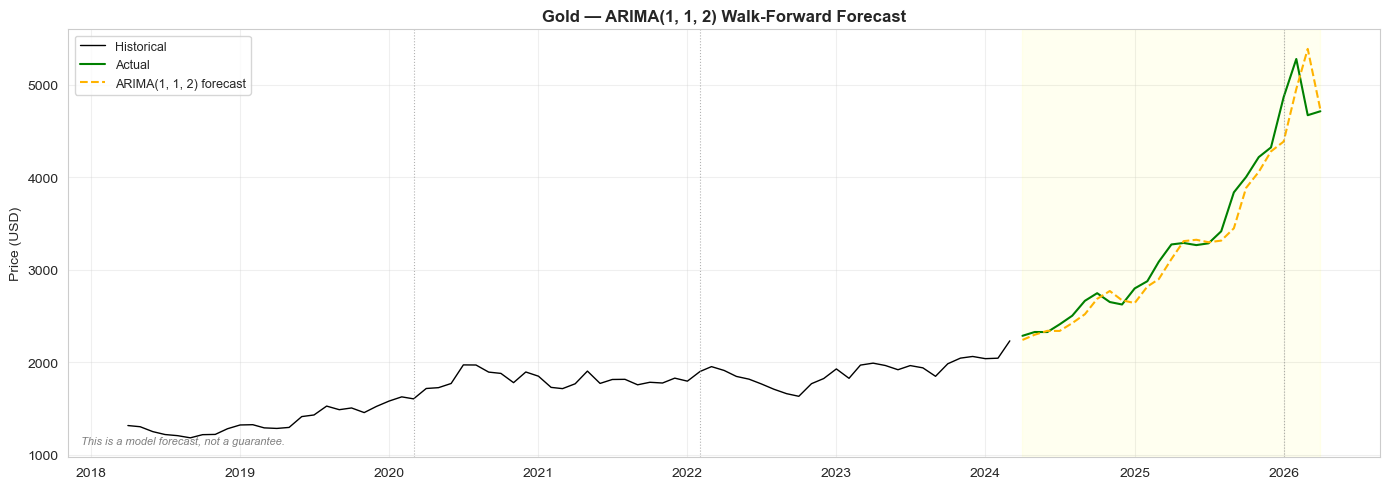

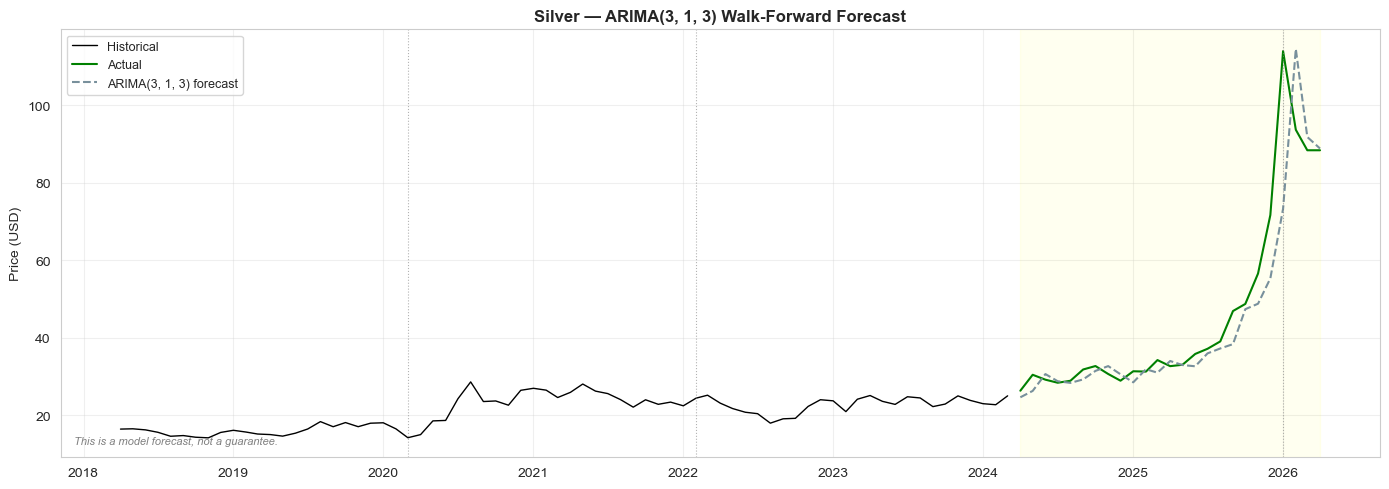

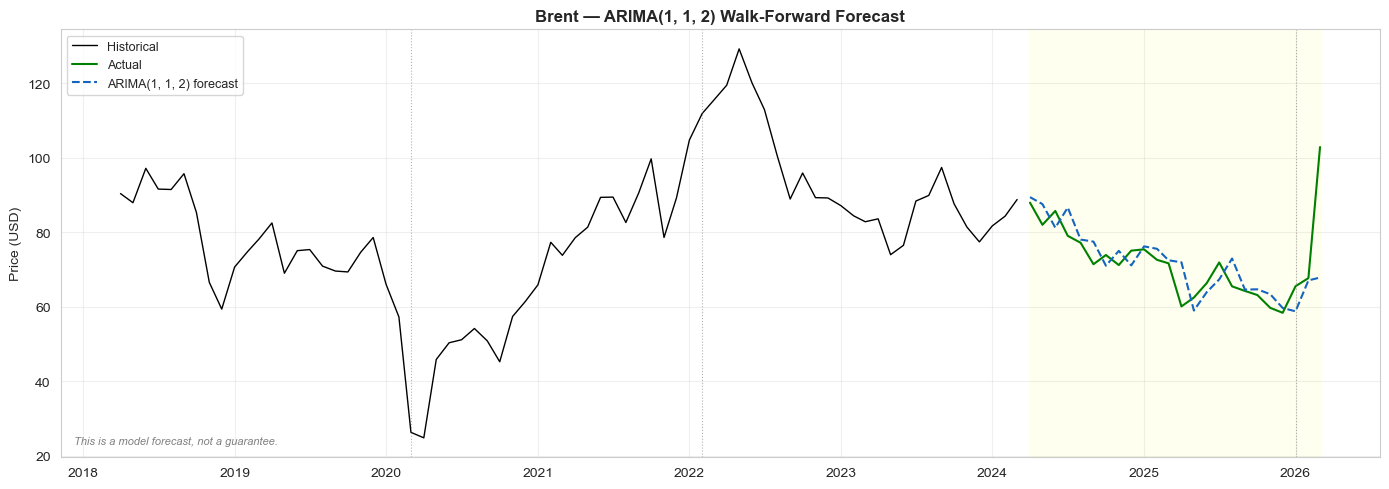

In [18]:
def plot_forecast(tr_df, te_df, pred_log, price_col, log_col, name, model_label, color='royalblue'):
    fig, ax = plt.subplots(figsize=(14, 5))
    hist = tr_df[price_col].iloc[-72:]  # last 6 years for clarity
    ax.plot(hist.index, hist.values, color='black', linewidth=1.0, label='Historical')

    actual_price = np.exp(te_df[log_col].values)
    pred_price   = np.exp(pred_log)

    ax.plot(te_df.index, actual_price, color='green',  linewidth=1.5, label='Actual')
    ax.plot(te_df.index, pred_price,   color=color,    linewidth=1.5, linestyle='--',
            label=f'{model_label} forecast')
    ax.axvspan(te_df.index[0], te_df.index[-1], alpha=0.06, color='yellow')

    for ev_date, ev_label in EVENTS.items():
        ed = pd.Timestamp(ev_date)
        if hist.index[0] <= ed <= te_df.index[-1]:
            ax.axvline(ed, color='gray', linestyle=':', alpha=0.6, linewidth=0.8)

    ax.set_title(f'{name} — {model_label} Walk-Forward Forecast', fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=9)
    ax.text(0.01, 0.03, 'This is a model forecast, not a guarantee.',
            transform=ax.transAxes, fontsize=8, color='gray', style='italic')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'forecast_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot ARIMA forecasts
plot_configs = [
    ('Gold',   gold_tr,   gold_te,   'gold',   'log_p', '#FFB300'),
    ('Silver', silver_tr, silver_te, 'silver', 'log_p', '#78909C'),
    ('Brent',  brent_tr,  brent_te,  'brent',  'log_p', '#1565C0'),
]
for name, tr, te, pcol, lcol, c in plot_configs:
    key = f'ARIMA_{name}'
    if key in preds_store:
        plot_forecast(tr, te, preds_store[key], pcol, lcol, name,
                      results[key]['Model'], color=c)

---
## Section 8 — GARCH / EGARCH Volatility (T1.6)

ARIMA captures conditional mean; GARCH captures **volatility clustering** (large shocks follow large shocks).  
EGARCH additionally captures asymmetry: negative shocks increase volatility more than positive ones.

In [19]:
def fit_garch(ret_series, vol_model='GARCH', p=1, q=1):
    """Fit GARCH(p,q) or EGARCH(p,q). Scale returns to % for numerical stability."""
    ret_pct = ret_series.dropna() * 100
    am = arch_model(ret_pct, vol=vol_model, p=p, q=q, dist='Normal', rescale=True)
    return am.fit(update_freq=0, disp='off')

garch_res = {}
# format() yerine .format() — Python 3.10'da f-string içinde iç içe tırnak desteklenmiyor
print('{:8s}  {:>18}  {:>18}  {:>10}'.format(
    'Asset', 'GARCH(1,1) AIC', 'EGARCH(1,1) AIC', 'Preferred'))
print('-' * 62)
for name, (df, col) in assets.items():
    g  = fit_garch(df['ret'], 'GARCH')
    eg = fit_garch(df['ret'], 'EGARCH')
    garch_res[name] = {'GARCH': g, 'EGARCH': eg}
    preferred = 'EGARCH' if eg.aic < g.aic else 'GARCH'
    print('{:8s}  {:>18.2f}  {:>18.2f}  {:>10}'.format(name, g.aic, eg.aic, preferred))

Asset         GARCH(1,1) AIC     EGARCH(1,1) AIC   Preferred
--------------------------------------------------------------
Gold                 6301.19             6320.33       GARCH
Silver               8834.83             8832.73      EGARCH
Brent                6116.16             5807.66      EGARCH


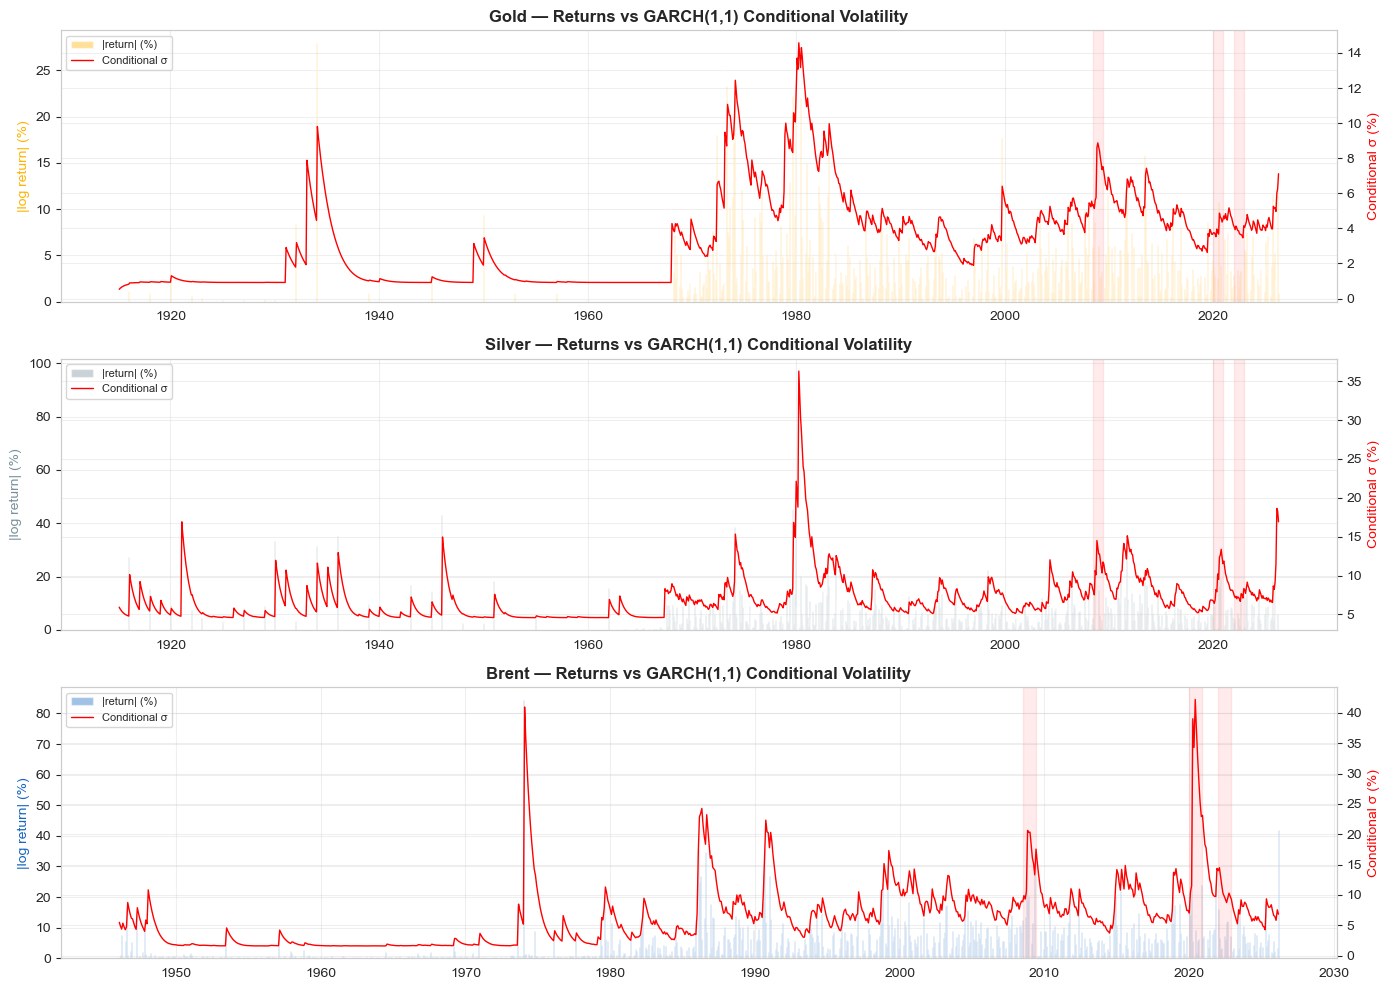

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
for ax, (name, (df, col)), c in zip(axes, assets.items(), colors.values()):
    ret_pct = df['ret'].dropna() * 100
    cond_vol = garch_res[name]['GARCH'].conditional_volatility  # annualised-equiv (%/mo)

    ax2 = ax.twinx()
    ax.bar(ret_pct.index, ret_pct.abs(), color=c, alpha=0.4, width=20, label='|return| (%)')
    ax2.plot(ret_pct.index, cond_vol, color='red', linewidth=1.0, label='Conditional σ')

    # Shade known crisis periods
    crisis_pairs = [('2008-07', '2009-06'), ('2020-01', '2020-12'), ('2022-01', '2022-12')]
    for cs, ce in crisis_pairs:
        ax.axvspan(pd.Timestamp(cs), pd.Timestamp(ce), alpha=0.08, color='red')

    ax.set_title(f'{name} — Returns vs GARCH(1,1) Conditional Volatility', fontweight='bold')
    ax.set_ylabel('|log return| (%)', color=c)
    ax2.set_ylabel('Conditional σ (%)', color='red')
    lines1, l1 = ax.get_legend_handles_labels()
    lines2, l2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, l1 + l2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'garch_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

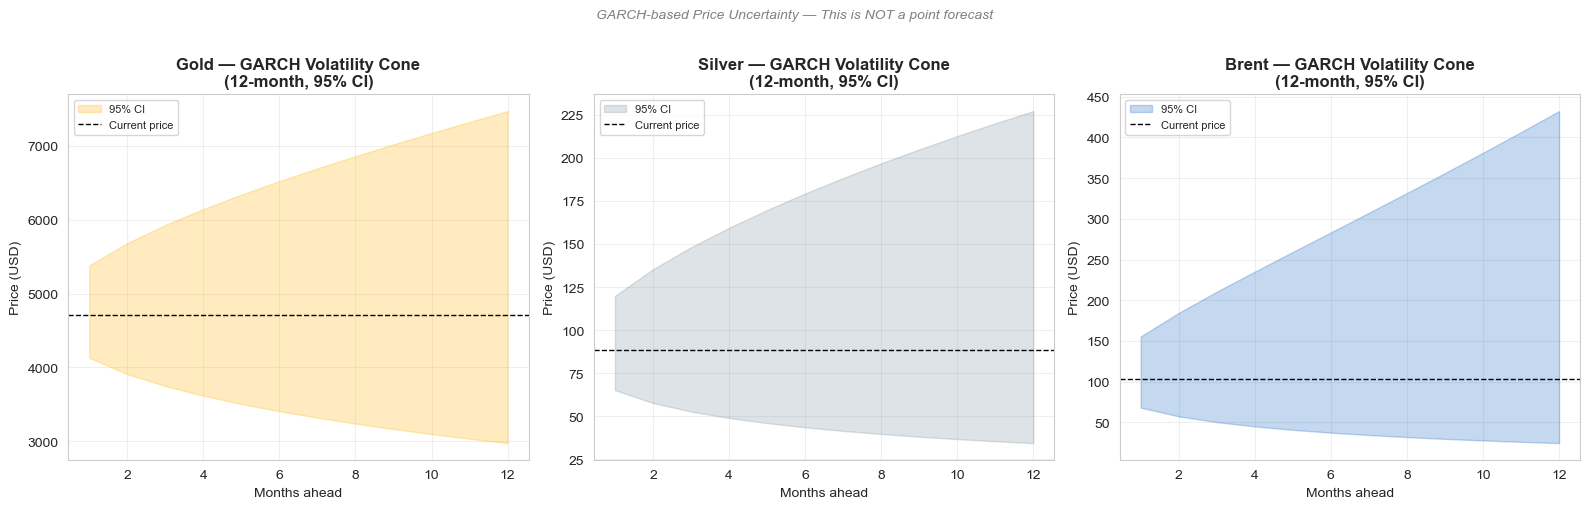

In [21]:
# GARCH 12-month volatility forecast (fan chart)
HORIZON = 12
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, (df, col)), c in zip(axes, assets.items(), colors.values()):
    g_res = garch_res[name]['GARCH']
    fcast = g_res.forecast(horizon=HORIZON)
    vol_fcast = np.sqrt(fcast.variance.iloc[-1].values)  # σ per month (%)

    last_price = df[col].iloc[-1]
    months_ahead = np.arange(1, HORIZON + 1)
    cumvol = np.sqrt(np.cumsum(vol_fcast ** 2)) / 100  # cumulative σ in price-return space

    upper = last_price * np.exp( 1.96 * cumvol)
    lower = last_price * np.exp(-1.96 * cumvol)

    ax.fill_between(months_ahead, lower, upper, alpha=0.25, color=c, label='95% CI')
    ax.axhline(last_price, color='black', linewidth=1.0, linestyle='--', label='Current price')
    ax.set_title(f'{name} — GARCH Volatility Cone\n(12-month, 95% CI)', fontweight='bold')
    ax.set_xlabel('Months ahead')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=8)

plt.suptitle('GARCH-based Price Uncertainty — This is NOT a point forecast', y=1.01,
             fontsize=10, color='gray', style='italic')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'garch_forecast_cone.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 — Results Summary & Diebold-Mariano Test (T1.7)

**Diebold-Mariano (DM) test** (Diebold & Mariano 1995): tests whether two models have equal predictive accuracy.  
H₀: equal accuracy. Negative DM → model1 is worse; positive → model2 is worse.  
We compare every ARIMA/ARIMAX against the Naive baseline.

In [22]:
def diebold_mariano(actual, pred1, pred2, loss='MSE'):
    """
    DM test for equal predictive accuracy.
    Returns (statistic, p-value). Two-sided test.
    loss: 'MSE' or 'MAE'
    """
    a, p1, p2 = map(np.asarray, [actual, pred1, pred2])
    if loss == 'MSE':
        e1, e2 = (a - p1) ** 2, (a - p2) ** 2
    else:
        e1, e2 = np.abs(a - p1), np.abs(a - p2)

    d = e1 - e2
    n = len(d)
    d_bar = d.mean()
    # Newey-West long-run variance (h=1 lag)
    gamma0 = np.var(d, ddof=1)
    gamma1 = np.cov(d[1:], d[:-1])[0, 1] if n > 2 else 0
    lrv = max(gamma0 + 2 * gamma1, 1e-12)
    dm_stat = d_bar / np.sqrt(lrv / n)
    p_val   = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return round(dm_stat, 4), round(p_val, 4)

print('Diebold-Mariano tests (ARIMA vs Naive, MSE-based):')
dm_rows = []
for name in ['Gold', 'Silver', 'Brent']:
    naive_key = f'Naive_{name}'
    arima_key = f'ARIMA_{name}'
    if naive_key not in preds_store or arima_key not in preds_store:
        continue

    # Need actual on price level for DM
    te = {'Gold': gold_te, 'Silver': silver_te, 'Brent': brent_te}[name]
    actual_p = np.exp(te['log_p'].values)
    naive_p  = np.exp(preds_store[naive_key])
    arima_p  = np.exp(preds_store[arima_key])

    dm_stat, dm_p = diebold_mariano(actual_p, naive_p, arima_p)
    sig = '***' if dm_p < 0.01 else ('**' if dm_p < 0.05 else ('*' if dm_p < 0.1 else ''))
    dm_rows.append({'Asset': name, 'DM stat': dm_stat, 'p-value': dm_p, 'Sig': sig,
                    'Interpretation': 'ARIMA better' if dm_stat < 0 else 'No improvement'})

dm_df = pd.DataFrame(dm_rows)
print(dm_df.to_string(index=False))

Diebold-Mariano tests (ARIMA vs Naive, MSE-based):
 Asset  DM stat  p-value Sig Interpretation
  Gold   0.6253   0.5318     No improvement
Silver   2.0166   0.0437  ** No improvement
 Brent  -0.5741   0.5659       ARIMA better


In [23]:
res_df = pd.DataFrame(results).T.reset_index(drop=True)
res_df[['RMSE', 'MAE', 'MAPE_%']] = res_df[['RMSE', 'MAE', 'MAPE_%']].astype(float)

# Pivot: MAPE by Model × Asset
pivot = res_df.pivot_table(index='Model', columns='Asset', values='MAPE_%', aggfunc='first')
print('MAPE (%) by Model × Asset:')
pivot.round(2)

MAPE (%) by Model × Asset:


Asset,Brent,Gold,Silver
Model,,,
"ARIMA(1, 1, 2)",6.55,3.90,NaN
"ARIMA(3, 1, 3)",NaN,NaN,8.58
ARIMAX+DXY,8.05,NaN,NaN
ARIMAX+VIX,NaN,4.14,NaN
Naive (RW),6.50,4.30,8.45


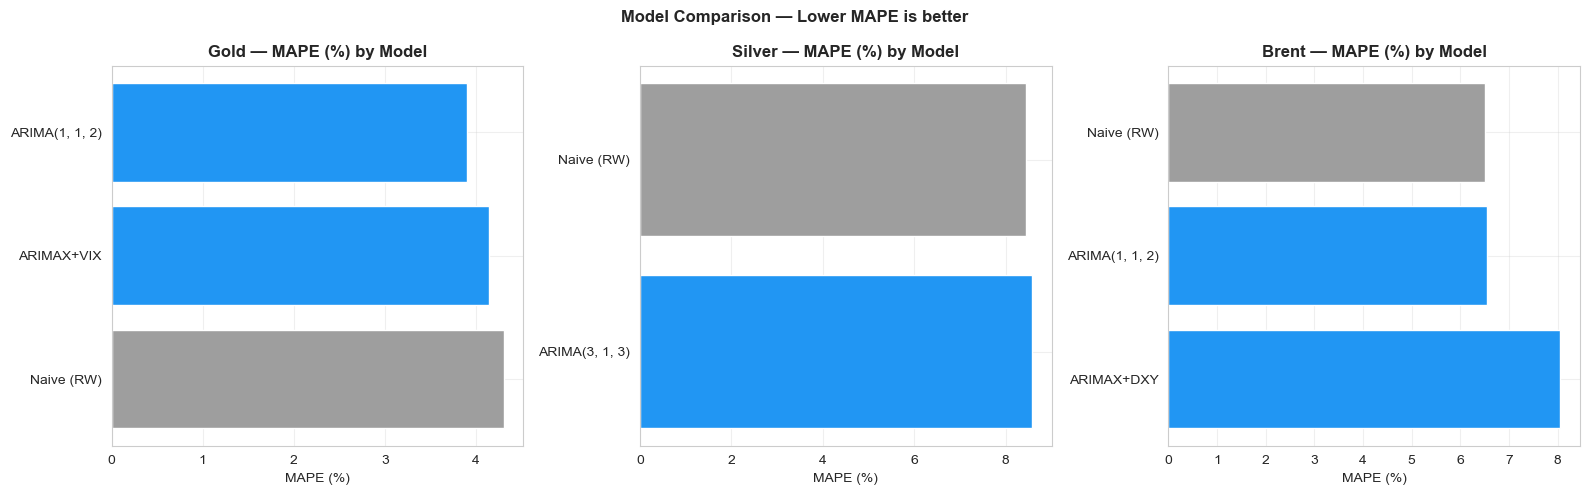

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, ['Gold', 'Silver', 'Brent']):
    subset = res_df[res_df['Asset'] == name].sort_values('MAPE_%')
    bar_colors = ['#2196F3' if 'ARIMA' in m else '#9E9E9E' for m in subset['Model']]
    ax.barh(subset['Model'], subset['MAPE_%'], color=bar_colors)
    ax.set_title(f'{name} — MAPE (%) by Model', fontweight='bold')
    ax.set_xlabel('MAPE (%)')
    ax.invert_yaxis()

plt.suptitle('Model Comparison — Lower MAPE is better', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

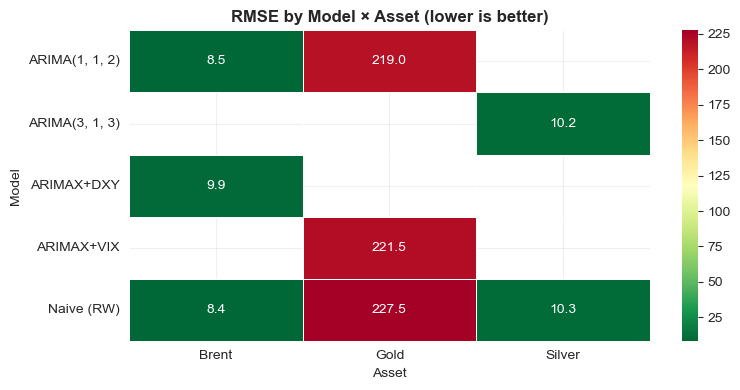

In [25]:
pivot_rmse = res_df.pivot_table(index='Model', columns='Asset', values='RMSE', aggfunc='first')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_rmse.astype(float).round(1), annot=True, fmt='.1f',
            cmap='RdYlGn_r', ax=ax, linewidths=0.5)
ax.set_title('RMSE by Model × Asset (lower is better)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rmse_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary — Tier 1 Complete

| Step | Status |
|------|--------|
| T1.1 Stationarity (ADF + KPSS) | ✅ |
| T1.2 Structural breaks (CUSUM + PELT) | ✅ |
| T1.3 Train/test split + walk-forward | ✅ |
| T1.4 Naive baseline | ✅ |
| T1.5 ARIMA / ARIMAX | ✅ |
| T1.6 GARCH / EGARCH volatility | ✅ |
| T1.7 RMSE/MAE/MAPE table + DM test | ✅ |

**Next steps (Tier 2):** Random Forest + LightGBM with lag features and GPR index → `forecasting_pipeline_tier2.ipynb`

> ⚠️ **Disclaimer:** All forecasts are generated by statistical models and carry significant uncertainty.
> They do not account for unforeseeable geopolitical events. Never use as sole basis for financial decisions.

In [26]:
# Tier 1 sonuçlarını kaydet — Tier 2 notebook buradan yükler
import json

save_path = OUTPUT_DIR / 'tier1_results.json'
results_serializable = {k: {kk: float(vv) if isinstance(vv, float) else vv
                             for kk, vv in v.items()}
                        for k, v in results.items()}
with open(save_path, 'w') as f:
    json.dump(results_serializable, f, indent=2)

# Tahminleri de kaydet (DM test için Tier 2'de kullanılabilir)
preds_path = OUTPUT_DIR / 'tier1_preds.json'
preds_serializable = {k: v.tolist() for k, v in preds_store.items()}
with open(preds_path, 'w') as f:
    json.dump(preds_serializable, f)

print(f'Tier 1 results saved → {save_path}')
print(f'Tier 1 preds saved   → {preds_path}')
print(f'Models: {list(results.keys())}')

Tier 1 results saved → ..\..\04_Outputs\tier1_results.json
Tier 1 preds saved   → ..\..\04_Outputs\tier1_preds.json
Models: ['Naive_Gold', 'Naive_Silver', 'Naive_Brent', 'ARIMA_Gold', 'ARIMA_Silver', 'ARIMA_Brent', 'ARIMAX_Gold', 'ARIMAX_Brent']
